# BlueSky Starter Packs's Description Analysis

### Methodology 1: HDBSCAN:

##### Q1: Qualitative:
**Motivation:** Starter packs description is usually very specific and community based focus, descriptions are usually look like this:
- “artists you should follow”

- “political accounts in the UK”

- “dog and cat rescue community”

- “my favorite VTubers”

- “comics artists and funny people”

As the result, we want to see if those short description actually form implicit community identity, even accounts in the starter packs might be varies for this Phase 2.

**Question:** Can we detect any signs of echo chambers through anayzing the language of starterpacks description?
Hypothesis: If the starter packs description is very specific and we can cluster and categorize them into a specific community using HDBSCAN.

**Why HDBSCAN?** 
- HDBSCAN will help us identify the density of each clusters
- If the cluster is dense, all starterpacks point formed around each other in dimensions -> Strong echo chambers
- We also do not have to deal with choosing the good K for clustering with KMeans

**Our Assumption when choosing this approach:**
- If the communities are alike, they are likely to use the same form of language.
- We also risk under-detecting subtle communities since this algorithm is stronly based on the density
- The tradeoff would be we can see the density of strong connected communities but subtle community would become noise.


##### Q2: Quantitative:
**Steps:**
1. Cleaned and extracted 109,597 starterpacks with description
2. Sample 10,000 of them
3. Generate 768-dim embeddings using all-mpnet-base-v2
4. Normalized embeddings for cosine similarity
5. Ran HDBSCAN with:
- min_cluster_size=50,40,10 (respectively)

- min_samples=10,2,1 (respectively)

- metric='euclidean'
6. Dimensionally reduced using Umap to visualize the clusters
7. Visualized the clusters in 2D and 3D

**Results:**
- There are 4 majors cluster with more than 50 starterpacks within them.
- However, the majorities(8865) of startpacks would fall into -1 clusters, which are all noises
- In the visualization, we can see a lot of gray dots, which are all noises. I decided to removed all noises for better visualization into clusters that actually matter.
- After all noises are removed for better visualization, the cluster are not form in a sperical form, amny of them are formed in a straightline. This is the reason why HDBSCAN detected lots of noise as it strongly focused on density and data points that wrap around a dense area as a sphere.

**Cluster Observation:**
- Artist/Comics

- Dog and Cat rescue

- Personal Favorite lists

- Tech and Game dev

- News and Politics

- My Favorite Artists

- Academia/Research community

- Hate Trump

- "Blue" Starter Packs (Politics)

- Immigrate from (X/Facebook) to BlueSky

...

##### Q3: Qualitative: 
- HDBSCAN only able to detect strongest echo chamers where the languages are very specific and similar to each other:
Examples: "Recuse dog and cat", "artist that worth follwing", "my favorite", "my fav Vtuber"

**Intepretation:** 
- The langauge starterpacks use for their description are highly similar within any strong clusters
=> We can see a bit of sign of echo chambers through those tightly connected communities as they used very specific languages.
- We need to look more into the outliers since lots of them are not categorized. Would it because the language they use or differnt or they are just totally differnt categories.

##### Q4: Next Step/New Question:
HDBSCAN results raised few questions:
- Can we detect echo chambers better using network structure rather than text alone?
- Would graph theory be a better way to clusters those startpacks through their description since HDBSCAN only based on density?
- Do they connected structually? As we also computing the structural connection between 2 starter packs through the accounts they share, we want to see if those description are also connected structually, which leads us to second methodology.


In [1]:
# Import Libraries
import json
from password import BSKY_USERNAME, BSKY_APP_PASSWORD
import pandas as pd
import re
from sentence_transformers import SentenceTransformer
import torch
import hdbscan
import umap.umap_ as umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
from sklearn.neighbors import NearestNeighbors
import networkx as nx
import igraph as ig
import leidenalg
import plotly.express as px

/Users/tkieu/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tkieu/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Install sentence-transformers package
#!pip install sentence-transformers
#!pip install hdbscan
#!pip install umap-learn
#!pip install plotly
#!pip install networkx python-igraph leidenalg

##### Read the Starterpacks URIs and Only Include Starterpacks URI and Description for Analysis:
We will only analysis on starterpacks that have descriptions. After fitering it, we end up with 109597 starterpacks.

In [3]:
df = pd.read_json("./data/Trang_accounts_all.jsonl", lines=True)
descriptions = df[["SP URI","SP Description"]]
descriptions = descriptions.dropna(subset=['SP Description'])
descriptions = descriptions.drop_duplicates()

In [4]:
descriptions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20525 entries, 26 to 2305830
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SP URI          20525 non-null  object
 1   SP Description  20525 non-null  object
dtypes: object(2)
memory usage: 481.1+ KB


#### Data Cleaning:

In [5]:
#Convert description to string type from object
descriptions["SP Description"] = descriptions["SP Description"].astype("string")

#Premiliary description (text) cleaning
descriptions["SP Description"] = (descriptions["SP Description"].str.lower()
                                                          .str.strip()
                                                          .str.replace(r"http\S+|www\.\S+", "", regex=True)
                                                          .str.replace(r"@\w+", "", regex=True)
                                                          .str.replace(r"\s+", " ", regex=True))

##### Create test/sub dataset and do clustering on:
We will stick to this subdata set in this phase 2 analysis and we will expand to full 109597 after fine tunning further in next phase.

In [6]:
test_df = descriptions

In [7]:
len(test_df)

20525

#### Generated 768-dim embeddings using all-mpnet-base-v2:
By using the all-mpnet-base-v2 embedding model, our descriptions will be turn in 768 dimensions vector. If 2 descriptions are similar to each other, two vector will point in the similar direction. After embedding, we will calculate dot product of vectors on a specific dimensions to check top vectors with higest similarity score (high dot product).

In [8]:
model = SentenceTransformer("intfloat/e5-base-v2")

# Convert text to "query style" for best e5 performance
texts = ["query: " + t for t in test_df["SP Description"].tolist()]

# Optional: use GPU if available
if torch.cuda.is_available():
    model = model.to("cuda")

embs = model.encode(texts, batch_size=64, show_progress_bar=True)

import numpy as np

embeddings = model.encode(
    texts,
    batch_size=64,          # you can tweak (32/64/128 depending on RAM)
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True    # good for cosine similarity / clustering
)

print(embeddings.shape)

Batches: 100%|██████████| 321/321 [01:12<00:00,  4.44it/s]


(20525, 768)


In [9]:
# Reset index
descriptions = descriptions.reset_index(drop=True)

In [10]:
def find_most_similar(i, k=10):
    """
    Print the starter pack at index `i` and list its top `k` most similar
    starter packs based on embedding similarity.

    Steps:
    - Retrieve the target embedding and its description/URI.
    - Compute dot-product similarities between the target embedding and all others.
    - Rank entries by similarity (excluding the target itself).
    - Print the top `k` matches along with their similarity score, URI, and description.
    """
    target_emb = embeddings[i]
    target_row = descriptions.loc[i]  # index now matches
    
    print("=== TARGET STARTER PACK ===")
    print("URI:", target_row["uri"])
    print("DESC:", target_row["description"])
    print("===========================\n")
    
    similarities = embeddings @ target_emb  # dot products
    
    top_idx = np.argsort(similarities)[::-1]
    top_idx = top_idx[top_idx != i]  # drop itself
    
    print(f"=== TOP {k} MOST SIMILAR ===")
    for rank, j in enumerate(top_idx[:k], start=1):
        row = descriptions.loc[j]
        print(f"{rank}. SIM={similarities[j]:.4f}")
        print("URI:", row["uri"])
        print("DESC:", row["description"])
        print()

In [11]:
find_most_similar(600, k=10)

=== TARGET STARTER PACK ===


KeyError: 'uri'

In [ ]:
# Create the HDBSCAN model
#### Tune minimum cluster size and min samples further if needed
clusterer_subset = hdbscan.HDBSCAN(
    metric='euclidean',          
    min_cluster_size=10,            # minimum cluster size 
    min_samples=2,                  # how strict about density
    cluster_selection_method='eom'
)

# Fit the HDBSCAN model
labels_subset = clusterer_subset.fit_predict(embeddings)
labels_subset

In [ ]:
# Add the cluster id as a column into test_df
test_df["cluster_id"] = labels_subset

In [ ]:
# Counting the clusters
test_df["cluster_id"].value_counts()

cluster_id
-1     8869
 12     242
 32     185
 30      59
 24      51
 7       42
 27      42
 34      39
 20      36
 18      27
 2       25
 35      24
 25      24
 0       23
 31      22
 23      18
 6       17
 9       17
 22      16
 29      16
 33      15
 11      15
 17      15
 14      14
 21      13
 28      13
 3       12
 13      12
 5       12
 19      12
 8       11
 1       11
 15      11
 10      10
 26      10
 4       10
 16      10
Name: count, dtype: int64

In [ ]:
# Evaluating clusters
for cid in sorted(test_df["cluster_id"].unique()):
    print(f"\n=== Cluster {cid} ===")
    print(test_df[test_df["cluster_id"] == cid]["SP Description"].tolist())


=== Cluster -1 ===
['education is the most powerful weapon which you can use to change the world. nelson mandela', 'for memoir authors and readers to connect!', 'nearly 100 mps, peers, ex-mps or ex-meps on bluesky who are involved with forging better relations with the eu. please let me know if there is someone you would like to add.', 'mps, councillors and others politicos in greater manchester', 'friendly wordle competition -vetted with artistic recaps by dame mighty', "broad assortment of artists, comic artists, funny people, and people i find interesting. this is for people who aren't following a lot of people and want a big variety of recommendations. some post nsfw images, so follow all at your own discretion", 'my favorite sources for news and information long before wapo, nyt, lat even hear about it.', 'seattle, portland, spokane - a collection of my favorite local journalists, writers, and news outlets, in addition to a few progressive politicians and lefty advocacy orgs to f

#### Reduce the dimension for Visualization: (UMAP)
Reason: 
- Easier to visualized with 2D or 3D
- Faster to train with smaller number of dimension since we have 768 dimensions right now

In [ ]:
# Reduce dimensions
umap_3d = umap.UMAP(
    n_neighbors=50,      
    n_components=3,      
    metric="cosine",
    random_state=42
).fit_transform(embeddings)

/Users/tkieu/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# Filter out noise points labeled as -1 (DBSCAN noise).
# `mask` is True for all non-noise points.
mask = labels_subset != -1

# Keep only the UMAP coordinates and labels for non-noise points.
umap_clean = umap_3d[mask]
labels_clean = labels_subset[mask]

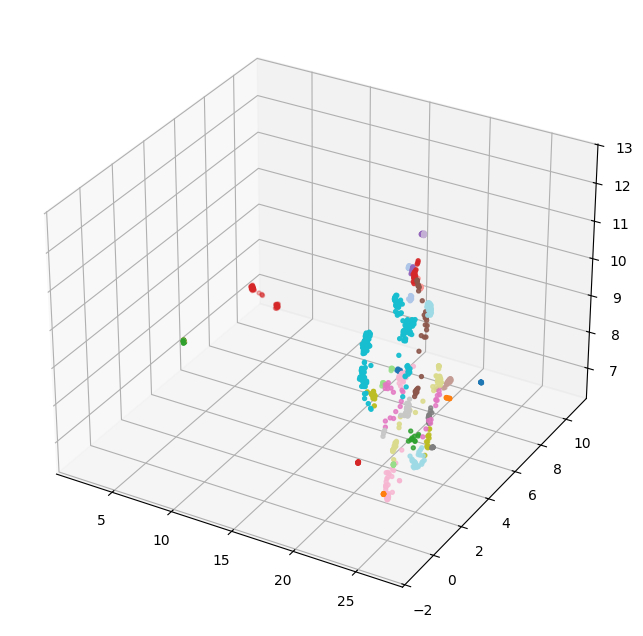

In [ ]:
# Visualized it in 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    umap_clean[:,0],
    umap_clean[:,1],
    umap_clean[:,2],
    c=labels_clean,
    cmap="tab20",
    s=8
)
plt.show()

In [ ]:
# Visualized in interactive 3D
df = pd.DataFrame({
    "x": umap_clean[:,0],
    "y": umap_clean[:,1],
    "z": umap_clean[:,2],
    "cluster": labels_clean
})

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="cluster",
    opacity=0.8,
)
fig.update_traces(marker=dict(size=3))
fig.show()

### Methodology 2: Community Detection:

##### Q1: Qualitative:
Our hypothesis all a long is echo chambers are a network structure where startpacks share accounts and have similar description. They are densly connected graph where starterpacks would share the accounts and their description describe or focus on a specific subgroup. We can also see the trend from the HDBSCAN that some starterpacks are strongly together and have little or no connection to other starterpacks.

**Question:** Can we detect echo chambers by constructing a similarity graph of starterpacks based on semantic embeddings?
**Motivation:** Since another analysis we did is constructing similarity graph of starter packs based on account shared so we want to combine the two analysis further down the road. And Community Detection (Leiden graph clustering) is also not limit by desity.
**Assumption:** 
- Similar descriptions imply ties between communities

- Echo chambers should appear as modular clusters

##### Q2: Quantitative:
**Processing Steps:**

1. Sampled 10,000 starterpacks (Using test_df from above)

2. Constructed kNN graph (k = 10) instead of calculate similarity score for every single one starterpacks (O(N^2) is not scalable)

3. Edge weights = cosine similarity

4. Converted graph to igraph

5. Ran Leiden with resolution = 1.0

6. Generated UMAP (2D & 3D) for visualization

7. Visualized 2D and 3D interactive visualization

**Result:**
- We ended up with 17 distinct communities
- Largest community has around 1000 packs
Notable community:
- Politics/Law/Governance
- Artists/Comics/Creators
- Dog/Cat Rescue
- Streamers/VTubers
- Authors/Writing
- Musicians/DJs


#### Q3:
Intepretation:
- Starterpacks that ended up in the same Leiden clusters are potentially: talking about the same topic, the same interest group and share the same cultural space.
- If they have weak external link that means they are totally irrelavent topic. politics vs art,...

Starterpacks appear to reinforce:

- niche identities (My fav)

- local social clusters

- language boundaries 

- subcultural grouping

Q4: Next Step:
1. Cross-validation: Compare HDBSCAN and Leiden clusters
- Does communities persist across methods?
2. Combinding the result of this analysis with the account similarity clustering for deeper analysis.

##### Construct KNN Graph

In [12]:
K = 20  # number of neighbors per node (you can try 10, 20, 30)

nn = NearestNeighbors(
    n_neighbors=K + 1,   # +1 because the nearest neighbor is itself
    metric="cosine"
)
nn.fit(embeddings)

distances, indices = nn.kneighbors(embeddings)

##### Calculate similarity:

In [13]:
sims = 1 - distances   # convert to similarity

##### Build Graph:

In [14]:
G = nx.Graph()

num_nodes = embeddings.shape[0]
G.add_nodes_from(range(num_nodes))  # node ids: 0..num_nodes-1

# build edges
sim_threshold = 0.3  # ignore very weak similarities; you can tweak this

for i in range(num_nodes):
    for j_idx, dist in zip(indices[i][1:], distances[i][1:]):  # skip self at [0]
        j = j_idx
        sim = 1.0 - dist
        
        if sim < sim_threshold:
            continue
        
        # add edge i-j with weight=similarity; if it already exists, keep max weight
        if G.has_edge(i, j):
            if sim > G[i][j]["weight"]:
                G[i][j]["weight"] = sim
        else:
            G.add_edge(i, j, weight=sim)

##### Convert to iGraph and Build Leiden:

In [15]:
# networkx → igraph
g = ig.Graph.from_networkx(G)

#### Leiden Community Detection:

In [16]:
partition = leidenalg.find_partition(
    g,
    leidenalg.RBConfigurationVertexPartition,  # or ModularityVertexPartition
    weights=g.es["weight"],
    resolution_parameter=1.0  # tune this; >1 → more, smaller communities
)

#### Generate UMAP for visualization:

In [17]:
umap_2d_sub = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    metric="cosine",
    random_state=42
).fit_transform(embeddings)

/Users/tkieu/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### Get Community ID Per Node:

In [18]:
num_nodes = g.vcount()  # or emb_sub.shape[0], or len(desc_sub)

community_ids = np.zeros(num_nodes, dtype=int)

for cid, community in enumerate(partition):
    for node in community:      # node is an integer vertex ID: 0..num_nodes-1
        community_ids[node] = cid

In [19]:
print("num_nodes =", num_nodes)
print("len(test_df) =", len(test_df))

num_nodes = 20525
len(test_df) = 20525


In [20]:
test_df["community_id"] = community_ids

In [ ]:
test_df

,SP URI,SP Description,cluster_id,community_id
26,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,education is the most powerful weapon which yo...,-1,3
140,at://did:plc:5i44ufyoaddlx2woq6jjooe2/app.bsky...,for memoir authors and readers to connect!,-1,11
287,at://did:plc:hyyr7fulewszq7evfnkvx2bd/app.bsky...,"nearly 100 mps, peers, ex-mps or ex-meps on bl...",-1,4
492,at://did:plc:7fiej65ln5nlyubac3ujduni/app.bsky...,"mps, councillors and others politicos in great...",-1,4
763,at://did:plc:4nlcdkzpa7nvbartn6hagkuc/app.bsky...,friendly wordle competition -vetted with artis...,-1,11
...,...,...,...,...
2305417,at://did:plc:6o2ksnicwjleyzxqmfuptmja/app.bsky...,i would like a start pack that is about witchc...,-1,5
2305425,at://did:plc:gbd5q7atssowccgipudtqxre/app.bsky...,here is a list of of our chapters and orgs clo...,-1,4
2305465,at://did:plc:h754nrifjxfzfqx5kls2safx/app.bsky...,for dem der søger om dansk statsborgerskab ell...,-1,8
2305546,at://did:plc:tmd6ytsephnhyendlhev5t4e/app.bsky...,"a place to find writers, lit mags and publishe...",-1,11


#### Visualized the clusterings/communities in 2D:

In [21]:

plot_df = pd.DataFrame({
    "x": umap_2d_sub[:,0],
    "y": umap_2d_sub[:,1],
    "community": community_ids
})
sample_size = min(4000, len(plot_df))   # choose 2000, 4000, 5000 etc
plot_sample = plot_df.sample(n=sample_size, random_state=42)

fig = px.scatter(
    plot_df,
    x="x", y="y",
    color="community",
    opacity=0.8,
    title="Leiden communities of starterpacks (subset)"
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(template="simple_white")
opacity=0.5
fig.show()



In [22]:
plot_df = pd.DataFrame({
    "x": umap_2d_sub[:, 0],
    "y": umap_2d_sub[:, 1],
    "community": community_ids.astype(str)
})
sample_size = min(4000, len(plot_df))
plot_sample = plot_df.sample(n=sample_size, random_state=42)
import pandas as pd
import plotly.express as px

plot_df = pd.DataFrame({
    "x": umap_2d_sub[:, 0],
    "y": umap_2d_sub[:, 1],
    "community": community_ids.astype(str)
})

sample_size = min(4000, len(plot_df))
plot_sample = plot_df.sample(n=sample_size, random_state=42)

fig = px.scatter(
    plot_sample,
    x="x",
    y="y",
    color="community",
    title="UMAP projection of Leiden communities",
    opacity=0.45,
    width=950,
    height=650
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    template="simple_white",
    legend_title_text="Community",
    xaxis_title="",
    yaxis_title=""
)

fig.show()

In [24]:
community_labels = {
0: "General personal recommendations / favorite people",
1: "Artists and creative creators (visual art, comics)",
2: "Academic experts and research communities",
3: "Animal rescue activism (dogs and cats)",
4: "Mixed social communities and hobby groups",
5: "Personal identity and lifestyle accounts",
6: "Gaming, streaming, and tech creator communities",
7: "Noise or test descriptions",
8: "Non-English European-language communities",
9: "Journalists, media, and political commentary",
10: "Sports and gaming niche communities",
11: "Writers, authors, and literary communities",
12: "Portuguese and Spanish speaking communities",
13: "General Bluesky starter packs and discovery lists",
14: "Multilingual Asian and Middle Eastern communities",
15: "Music fandom communities",
16: "Feed curation and follow recommendation lists",
17: "Personal campaigns and niche activism lists",
18: "Spam or promotional service accounts"
}

In [26]:
import pandas as pd
import numpy as np
import plotly.express as px

plot_df = pd.DataFrame({
    "x": umap_2d_sub[:,0],
    "y": umap_2d_sub[:,1],
    "community_id": community_ids
})

# map community labels
plot_df["label"] = plot_df["community_id"].map(community_labels)

top_k = 5

# find top 5 communities
top_comms = plot_df["community_id"].value_counts().head(top_k).index

# create plotting label
plot_df["plot_label"] = plot_df["community_id"].apply(
    lambda x: community_labels[x] if x in top_comms else "Other"
)

plot_sample = plot_df.sample(n=min(4000, len(plot_df)), random_state=42)

fig = px.scatter(
    plot_sample,
    x="x",
    y="y",
    color="plot_label",
    opacity=0.5,
    title="UMAP projection of starter packs colored by Leiden community",
    width=900,
    height=600
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    template="simple_white",
    legend_title="Community",
    xaxis_title="",
    yaxis_title=""
)

fig.show()

#### Visualized the community in 3D:

In [ ]:
umap_3d = umap.UMAP(
    n_neighbors=30,
    n_components=3,     # ⭐ make it 3D
    metric="cosine",
    random_state=42
).fit_transform(embeddings)   # or emb_test or emb_sub

plot_df = pd.DataFrame({
    "x": umap_3d[:, 0],
    "y": umap_3d[:, 1],
    "z": umap_3d[:, 2],
    "community": community_ids
})

sample_size = min(3000, len(plot_df))
plot_sample = plot_df.sample(n=sample_size, random_state=42)



fig = px.scatter_3d(
    plot_sample,
    x="x",
    y="y",
    z="z",
    color="community",
    opacity=0.6,
    title=f"Leiden communities (3D UMAP/Sample of {sample_size})"
)

fig.update_traces(marker=dict(size=2))   # smaller points = clearer
fig.show()

/Users/tkieu/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
print(len(np.unique(community_ids)))

19


#### Show StarterPacks Description by Community:

In [27]:
def show_community(cid, n=15):
    group = test_df[test_df["community_id"] == cid]
    print(f"=== Community {cid} (size={len(group)}) ===")
    for _, row in group.head(n).iterrows():
        print("-", row["SP Description"])
    print()

for cid in sorted(test_df["community_id"].unique()):
    show_community(cid, n=8)

=== Community 0 (size=2531) ===
- mps, councillors and others politicos in greater manchester
- experts and commentators on privacy law. also check out privacy law starter pack - part 2 
- people and organizations focusing on fourth amendment, criminal procedure, and government surveillance.
- professors and deans at the george washington university law school.
- thought leaders in artificial intelligence law and policy
- more great experts and commentators on privacy law, including ai, data security, and technology. also check out privacy law starter pack - part 1 
- search. observe. protect - elastic's devrel and tech teams sharing content, best practices, conference highlights, and much more!
- all the people and organisations helping to make localgov websites better and some other gems of humans too. ask to be added this is no where near everyone yet!

=== Community 1 (size=2248) ===
- these are just some of my favorite folks who post things i look forward to seeing every day. ✌🏻
-

## Add Community Label:
So I hand labeling each communities and stored it in a jsonl file. Now I attach it to test_df

In [ ]:
### Read jsonl file
label = pd.read_json("./data/Clusters_labels.jsonl", lines=True)

In [ ]:
label

,community_id,label,confidence
0,0,General personal recommendations / favorite pe...,0.70
1,1,"Artists and creative creators (visual art, com...",0.92
2,2,Academic experts and research communities (law...,0.88
3,3,Animal rescue activism (dogs and cats),0.98
4,4,Mixed social communities and hobby groups,0.45
5,5,Personal identity and lifestyle accounts,0.65
6,6,"Gaming, streaming, and tech creator communities",0.83
7,7,Noise or test descriptions,0.99
8,8,Non-English European-language communities,0.80
9,9,"Journalists, media, and political commentary",0.95


In [ ]:
# Add the label Column
test_df = test_df.merge(label, on="community_id", how="left")

In [ ]:
test_df

,SP URI,SP Description,cluster_id,community_id,label,confidence
0,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,education is the most powerful weapon which yo...,-1,3,Animal rescue activism (dogs and cats),0.98
1,at://did:plc:5i44ufyoaddlx2woq6jjooe2/app.bsky...,for memoir authors and readers to connect!,-1,11,"Writers, authors, and literary communities",0.91
2,at://did:plc:hyyr7fulewszq7evfnkvx2bd/app.bsky...,"nearly 100 mps, peers, ex-mps or ex-meps on bl...",-1,4,Mixed social communities and hobby groups,0.45
3,at://did:plc:7fiej65ln5nlyubac3ujduni/app.bsky...,"mps, councillors and others politicos in great...",-1,4,Mixed social communities and hobby groups,0.45
4,at://did:plc:4nlcdkzpa7nvbartn6hagkuc/app.bsky...,friendly wordle competition -vetted with artis...,-1,11,"Writers, authors, and literary communities",0.91
...,...,...,...,...,...,...
20520,at://did:plc:6o2ksnicwjleyzxqmfuptmja/app.bsky...,i would like a start pack that is about witchc...,-1,5,Personal identity and lifestyle accounts,0.65
20521,at://did:plc:gbd5q7atssowccgipudtqxre/app.bsky...,here is a list of of our chapters and orgs clo...,-1,4,Mixed social communities and hobby groups,0.45
20522,at://did:plc:h754nrifjxfzfqx5kls2safx/app.bsky...,for dem der søger om dansk statsborgerskab ell...,-1,8,Non-English European-language communities,0.80
20523,at://did:plc:tmd6ytsephnhyendlhev5t4e/app.bsky...,"a place to find writers, lit mags and publishe...",-1,11,"Writers, authors, and literary communities",0.91


### Turn Dataset into Jsonl file to attach to Starterpack Median Analysis

In [ ]:
test_df.to_json("Community_Detection.jsonl", orient="records", lines=True)